<a href="https://colab.research.google.com/github/AmedeeRoy/BirdGAN/blob/main/code/basicGAN/GAN_lstm_local_binary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GAN

In [ ]:
# mount google drive
from google.colab import drive
drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
%cd drive/My\ Drive/

/content/drive/My Drive


## load data

In [ ]:
# import python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import datetime as dt
import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader, Dataset
import torchvision as tv

In [ ]:
### BINARY TRAJ

nb_traj = 500
length = 200
traj = np.zeros((nb_traj, length))

for i in range(nb_traj):
    l = np.random.randint(2,length/2)
    st = np.random.randint(1, length-l-1)

    traj[i,st:st+l] = 1

In [ ]:
class TrajDataSet(Dataset):
    def __init__(self,  traj, transform=None):
        
        self.traj = traj   # save trips
        self.transform = transform

    def __len__(self):
        return self.traj.shape[0]

    def __getitem__(self, idx):
        sample = traj[idx,:]
        if self.transform:
            sample = self.transform(sample)
        return sample

class ToTensor(object):
    """Convert ndarrays in sample to Tensors."""
    def __call__(self, sample):
        return torch.FloatTensor(sample)

In [ ]:
# hyperparameters
batch_size = 100

## reduce size dataset
train_set = TrajDataSet(traj, transform= ToTensor())
train_loader = DataLoader(train_set, batch_size=batch_size, num_workers = 0, shuffle = True, drop_last=True)

In [ ]:
x =  next(iter(train_loader))

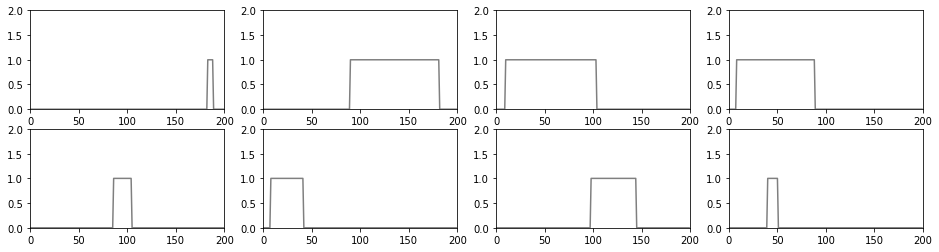

In [ ]:
plt.figure(figsize = (16,4))

for i in range(8):
  plt.subplot(2,4,i+1)
  plt.plot(x.numpy()[i,:], c = 'black', alpha = 0.5)
  plt.xlim(0,length)
  plt.ylim(0,2)


## deep networks

Architecture guidelines for stable Deep Convolutional GANs (Radford et al. 2016)

- Replace any pooling layers with strided convolutions (discriminator) and fractional-strided
convolutions (generator).
- Use batchnorm in both the generator and the discriminator.
- Remove fully connected hidden layers for deeper architectures.
- Use ReLU activation in generator for all layers except for the output, which uses Tanh.
- Use LeakyReLU activation in the discriminator for all layers.



In [ ]:
import torch
from torch import nn
from torch import optim
import torchvision as tv
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

## LSTM

In [ ]:
class LSTMGenerator(nn.Module):
    """An LSTM based generator. It expects a sequence of noise vectors as input.
    Args:
        in_dim: Input noise dimensionality
        out_dim: Output dimensionality
        n_layers: number of lstm layers
        hidden_dim: dimensionality of the hidden layer of lstms
    Input: noise of shape (batch_size, seq_len, in_dim)
    Output: sequence of shape (batch_size, seq_len, out_dim)
    """
    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(25, 20, 1, batch_first=True, bias = False)
        self.linear = nn.Sequential(
                        nn.Linear(20,20),
                        nn.Tanh(),
                        nn.Linear(20,20),
                        nn.Tanh(),
                        nn.Linear(20, 1),
                        nn.Tanh()
                      )


    def forward(self, z):

      window = 5
      traj = []

      xx = torch.zeros((batch_size, window, 20))
      
      h_0 = torch.autograd.Variable(torch.randn(1, batch_size, 20)) #hidden state
      c_0 = torch.autograd.Variable(torch.randn(1, batch_size, 20)) #internal stat

      for i in range(window, z.shape[2]):
        # merge input
        zz = z[:,:,i-window:i].reshape((batch_size, window, 5))
        input = torch.cat([xx,zz], 2)

        # # init LSTM cells  (batch, seq, feature)
        xx, _ = self.lstm(input, (h_0, c_0))
        traj.append(xx[:,-1,:].view(batch_size,1,20))

        
      out = torch.cat(traj, 1)
      out = self.linear(out)
      out = out.view(batch_size, 1, 200)
      

      return out#.cumsum(out, 2)

In [ ]:
gen = LSTMGenerator()
z = torch.rand((batch_size, 5, 205)) # (batch, features, len)

out = gen(z)
out.shape

torch.Size([100, 1, 200])

In [ ]:
class CNNDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()

                
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 8,  kernel_size = 4, stride = 2, padding = 1, bias = False),
            nn.BatchNorm1d(8),
            nn.LeakyReLU(0.2, inplace=False),

            nn.Conv1d(8, 16,  kernel_size = 4, stride = 2, padding = 1, bias = False),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.2, inplace=False),

            nn.Conv1d(16, 1, kernel_size=50, stride=2, padding=0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):

        out = self.cnn(x.view((batch_size, 1, 200)))
        return out.squeeze(1)


In [ ]:
dis = CNNDiscriminator()
dis(out).shape

torch.Size([100, 1])

# training

In [ ]:
def weights_init(m):
    """
    This function initializes the model weights randomly from a 
    Normal distribution. This follows the specification from the DCGAN paper.
    https://arxiv.org/pdf/1511.06434.pdf
    Source: https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html
    """
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# generator = CNNGenerator().to(device)
generator = LSTMGenerator().to(device)
discriminator = CNNDiscriminator().to(device)
# discriminator = LSTMDiscriminator().to(device)


# ### WEIGHT INITIALIZATION
generator.apply(weights_init)
discriminator.apply(weights_init)

criterion = nn.BCELoss()

lr = 0.0002
optim_d = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
optim_g = optim.Adam(generator.parameters(),lr= lr, betas=(0.5, 0.999))

target_ones = torch.ones((batch_size, 1), device=device)
target_zeros = torch.zeros((batch_size, 1), device=device)

Epoch [1/5000] -----------------------------------------------------------------------------
G: 1.1395578533411026, Dr : 0.8198002427816391, Df : 0.6714585646986961


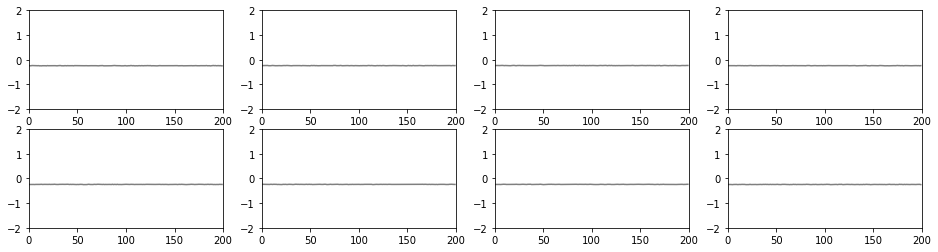

Epoch [201/5000] -----------------------------------------------------------------------------
G: 5.069329679012299, Dr : 0.025233157444745302, Df : 0.029366521630436182


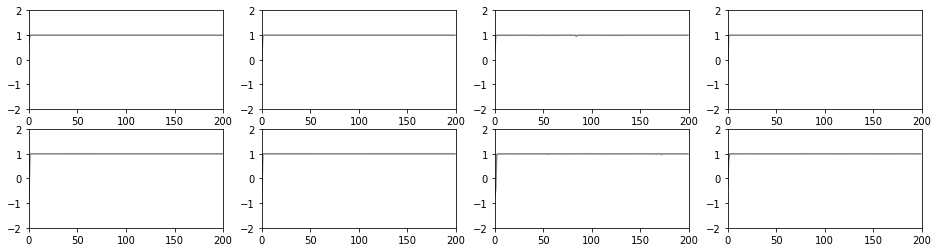

Epoch [401/5000] -----------------------------------------------------------------------------
G: 3.95208877325058, Dr : 0.8618615567684174, Df : 0.45735385827720165


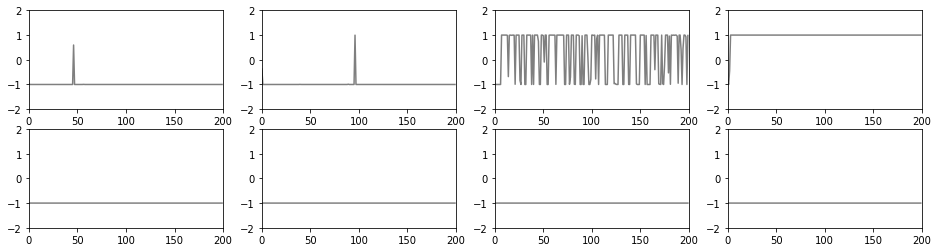

Epoch [601/5000] -----------------------------------------------------------------------------
G: 7.55135440826416, Dr : 0.004413254151586443, Df : 0.004911157768219709


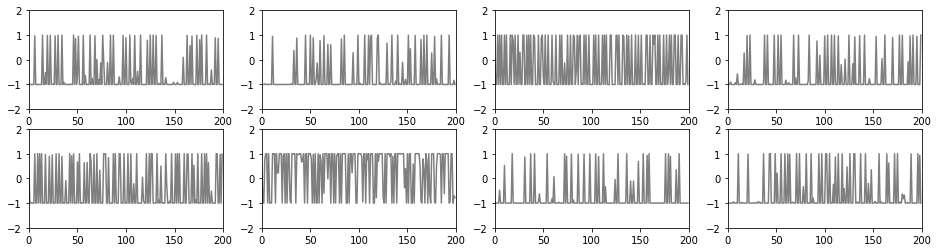

Epoch [801/5000] -----------------------------------------------------------------------------
G: 7.137730002403259, Dr : 0.005191091157030314, Df : 0.007444065995514393


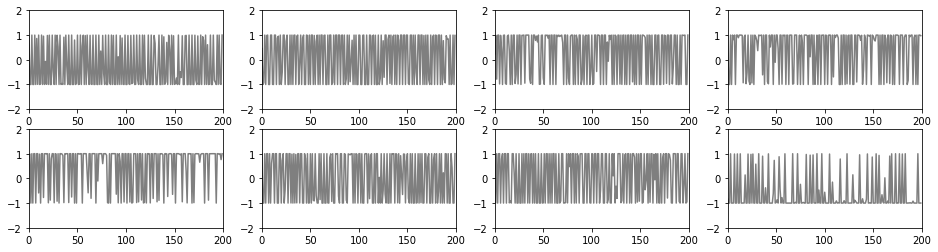

Epoch [1001/5000] -----------------------------------------------------------------------------
G: 6.191486358642578, Dr : 0.13280861498788, Df : 0.1493382970802486


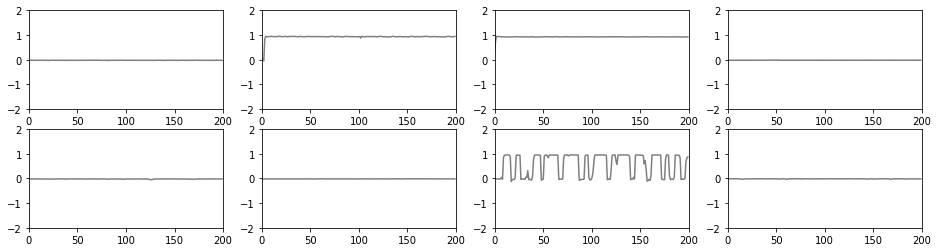

Epoch [1201/5000] -----------------------------------------------------------------------------
G: 7.351622819900513, Dr : 0.0024207669775933027, Df : 0.004489845363423228


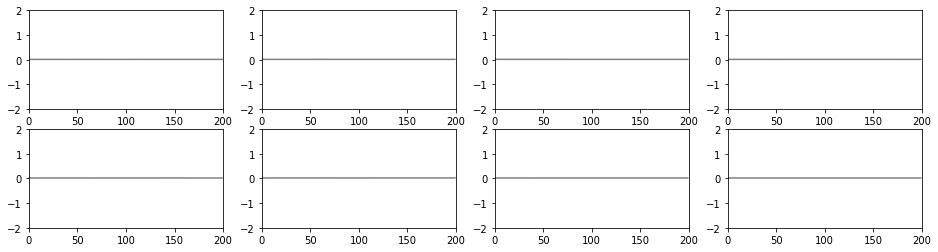

Epoch [1401/5000] -----------------------------------------------------------------------------
G: 9.595688939094543, Dr : 0.0016018268070183694, Df : 0.002163830737117678


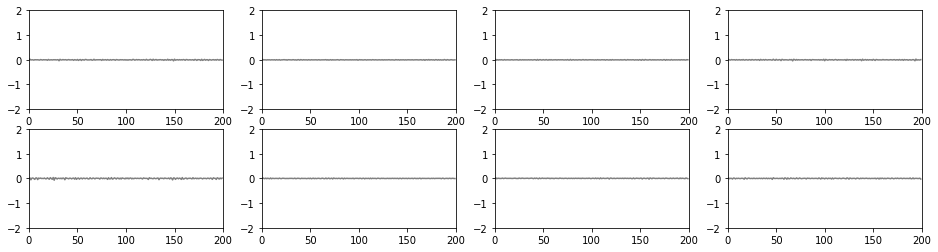

Epoch [1601/5000] -----------------------------------------------------------------------------
G: 10.10631549358368, Dr : 0.013064527651295066, Df : 0.00484276027418673


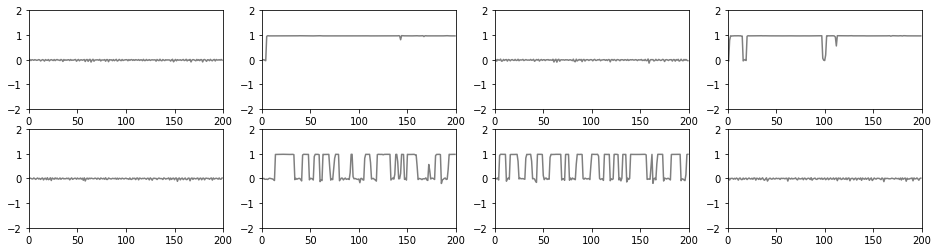

Epoch [1801/5000] -----------------------------------------------------------------------------
G: 11.393715620040894, Dr : 0.01621855143457651, Df : 0.011650550528429449


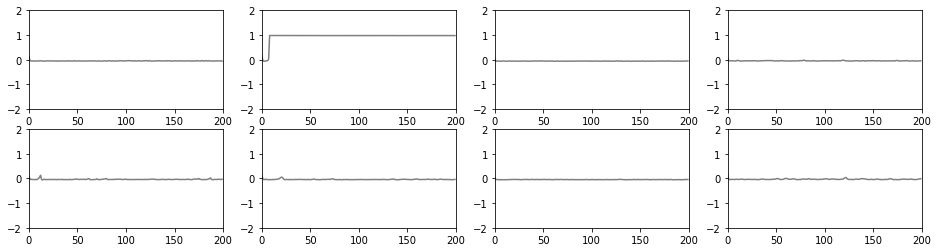

Epoch [2001/5000] -----------------------------------------------------------------------------
G: 8.520954608917236, Dr : 0.0033970582007896155, Df : 0.004494495748076588


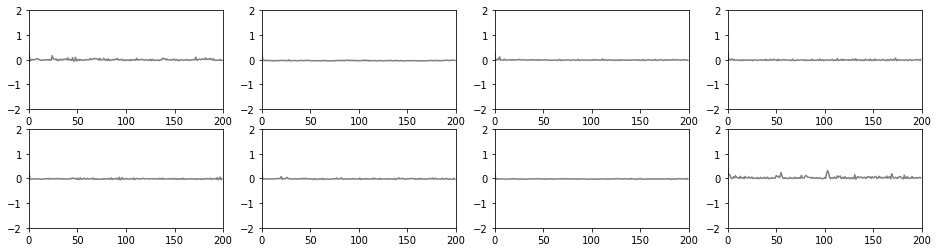

Epoch [2201/5000] -----------------------------------------------------------------------------
G: 9.974035024642944, Dr : 0.0010917160398093984, Df : 0.0013713844818994403


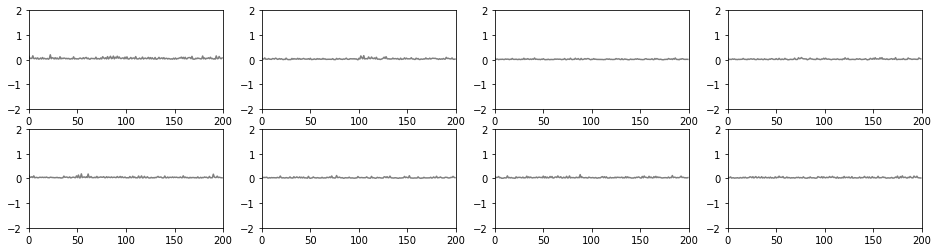

Epoch [2401/5000] -----------------------------------------------------------------------------
G: 11.248173236846924, Dr : 0.00022582085875910707, Df : 0.0006451457520597614


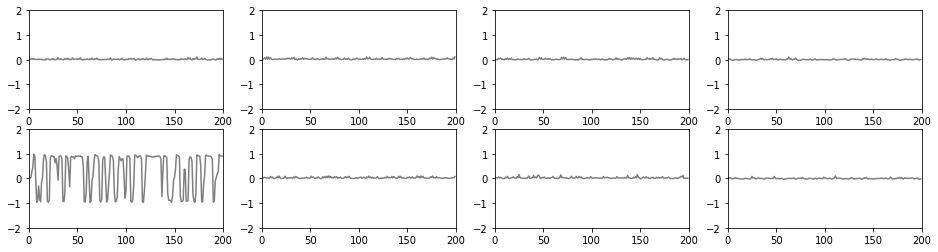

Epoch [2601/5000] -----------------------------------------------------------------------------
G: 12.204149723052979, Dr : 0.0002771723266050685, Df : 0.00034864273766288534


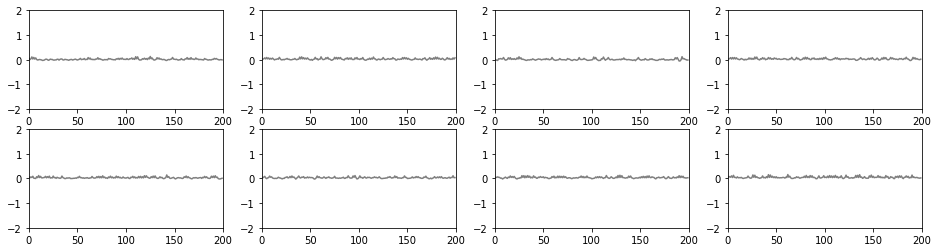

Epoch [2801/5000] -----------------------------------------------------------------------------
G: 10.550513982772827, Dr : 0.007441172609105706, Df : 0.007692460669204593


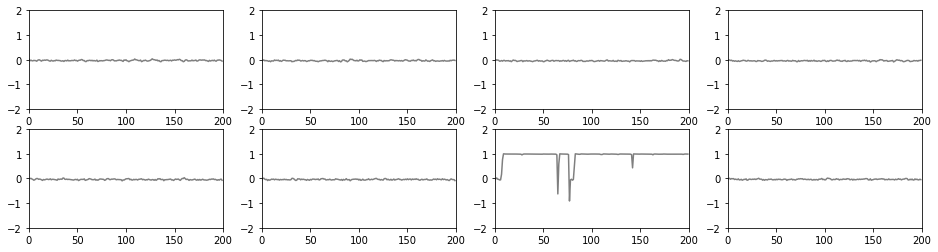

Epoch [3001/5000] -----------------------------------------------------------------------------
G: 11.61875057220459, Dr : 0.00021885136084165424, Df : 0.0005532810027943924


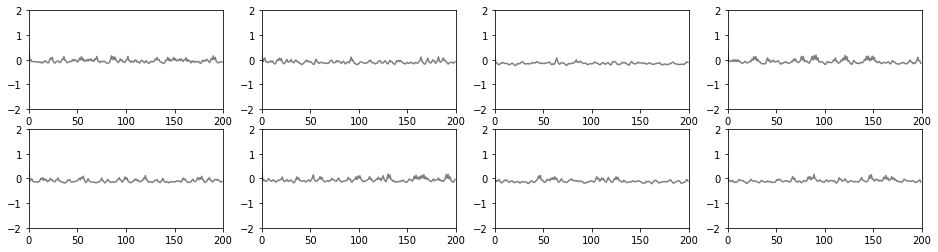

Epoch [3201/5000] -----------------------------------------------------------------------------
G: 12.243411540985107, Dr : 9.982137271435931e-05, Df : 0.00023071798932505772


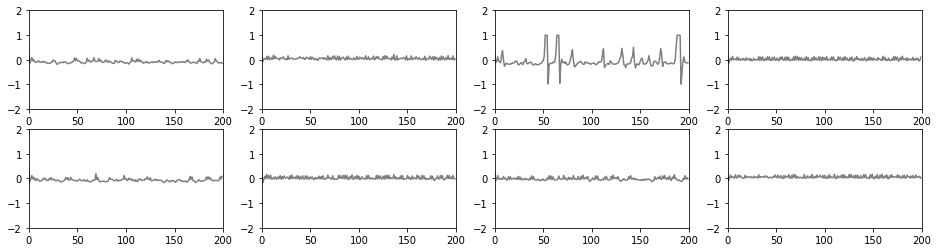

Epoch [3401/5000] -----------------------------------------------------------------------------
G: 12.965105295181274, Dr : 8.635767244413728e-05, Df : 0.0002986118270200677


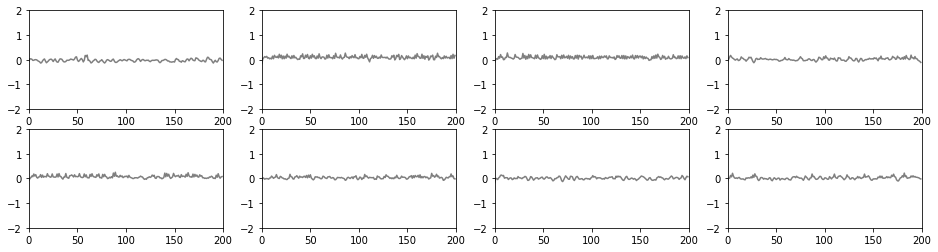

Epoch [3601/5000] -----------------------------------------------------------------------------
G: 10.118228793144226, Dr : 0.03752917633391917, Df : 0.041287561994977295


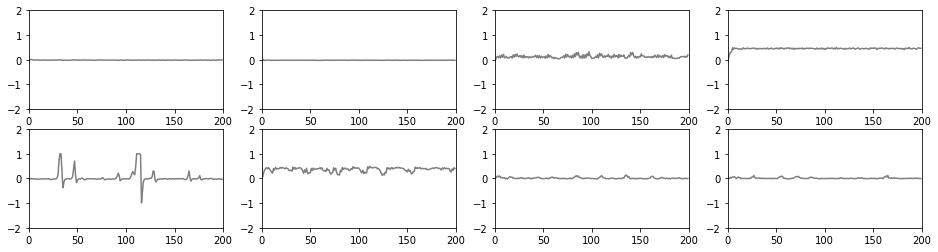

Epoch [3801/5000] -----------------------------------------------------------------------------
G: 10.979384422302246, Dr : 0.0008871028112480417, Df : 0.009295276046032086


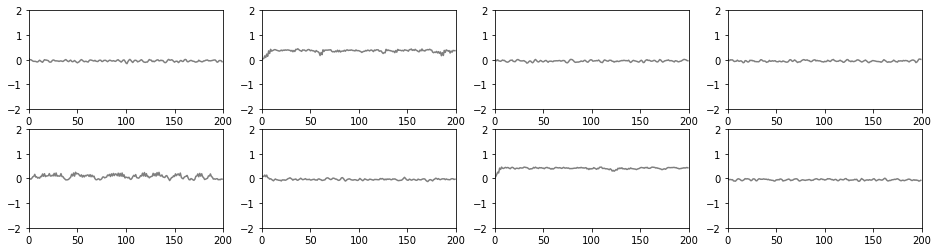

Epoch [4001/5000] -----------------------------------------------------------------------------
G: 11.90025782585144, Dr : 0.0006342652268358506, Df : 0.0007845873333280906


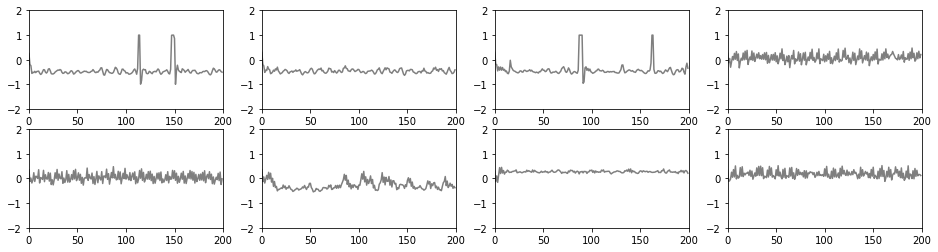

Epoch [4201/5000] -----------------------------------------------------------------------------
G: 13.087743997573853, Dr : 0.0003894005458278116, Df : 0.0006142556594568305


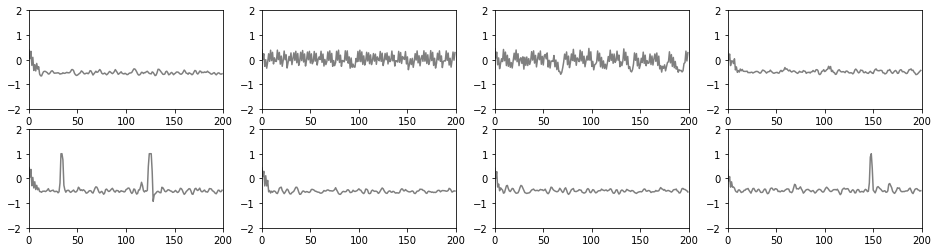

Epoch [4401/5000] -----------------------------------------------------------------------------
G: 12.998150110244751, Dr : 0.00012870151840616018, Df : 0.00020391725774970837


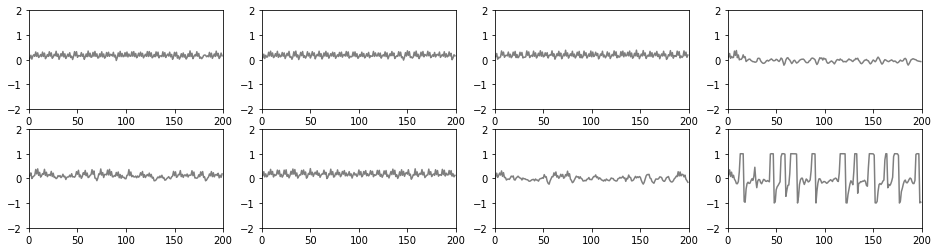

Epoch [4601/5000] -----------------------------------------------------------------------------
G: 13.891536474227905, Dr : 0.00014720875424245605, Df : 0.00014911164907971397


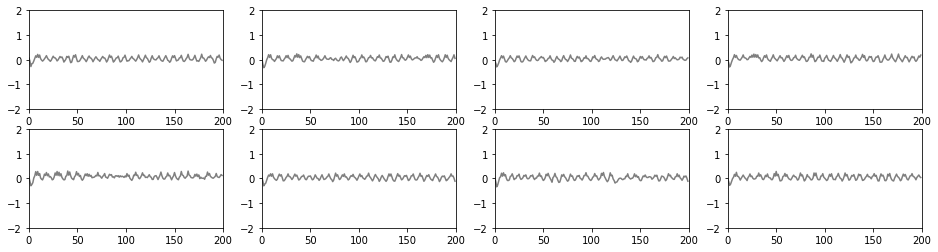

Epoch [4801/5000] -----------------------------------------------------------------------------
G: 15.05618143081665, Dr : 4.243843295625993e-05, Df : 7.080451723595615e-05


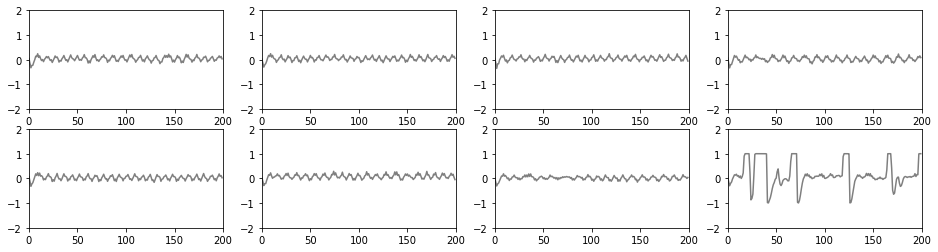

In [ ]:
# Train the model
nb_epoch = 5000

for epoch in range(nb_epoch):
    i = 0

    # if epoch%50 == 0:
    #     lr /= 10
    #     optim_d = optim.Adam(discriminator.parameters(), lr=lr)
    #     optim_g = optim.Adam(generator.parameters(),lr=lr)

    loss_g_running, loss_d_real_running, loss_d_fake_running = 0, 0, 0
    for batch, x in enumerate(train_loader):
        
        i+= 1
        #### TRAIN DISCRIMINATOR
        ## true samples
        x = x.to(device)

        discriminator.zero_grad()
        pred_real = discriminator(x)
        loss_real = criterion(pred_real, target_ones)

        ## false samples
        z = torch.rand((batch_size, 5, 205), device=device)
        with torch.no_grad():
            fake_samples = generator(z)
        pred_fake = discriminator(fake_samples)
        loss_fake = criterion(pred_fake, target_zeros)
        
        # combine
        loss = (loss_real + loss_fake) / 2
        loss.backward()
        optim_d.step()

        loss_d_real_running += loss_real.item()
        loss_d_fake_running += loss_fake.item()
        
        #### TRAIN GENERATOR
        generator.zero_grad()
        z = torch.rand((batch_size, 5, 205), device=device) 

        generated = generator(z)
        classifications = discriminator(generated)
        loss = criterion(classifications, target_ones)
        loss.backward()
        optim_g.step()

        loss_g_running += loss.item()
    
    if epoch%200 == 0:
      print('Epoch [{}/{}] -----------------------------------------------------------------------------'
          .format(epoch+1, nb_epoch, i, len(train_loader)))
      print('G: {}, Dr : {}, Df : {}'
          .format(loss_g_running/batch, loss_d_real_running/batch, loss_d_fake_running/batch))
      
      traj_sim = generated.detach().numpy()
      plt.figure(figsize = (16,4))
      for i in range(8):
        plt.subplot(2,4,i+1)
        plt.plot(traj_sim[i,0,:], c = 'black', alpha = 0.5)
        plt.xlim(0,length)
        plt.ylim(-2,2)

      plt.show()
      plt.close()



In [ ]:
# torch.save(generator, 'basicGAN_cnn_G.pt')
# torch.save(discriminator, 'basicGAN_cnn_D.pt')

# # generator = torch.load('basicGAN_cnn_G.pt')
# # discriminator = torch.load('basicGAN_cnn_D.pt')